# Notebook 14: Exchange Rate Volatility & Credit Risk Transmission

This notebook constructs monthly exchange rate variables from daily data and builds a 4-variable VAR to analyze the impact of exchange rate instability on KHR and USD credit risk spreads.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True

### 2. Load Credit Spreads and Fed Funds Rate

In [2]:
# Spreads
khr_spreads = pd.read_csv('data/processed/spreads_khr_new_amount.csv')
usd_spreads = pd.read_csv('data/processed/spreads_usd_new_amount.csv')
khr_spreads['date'] = pd.to_datetime(khr_spreads['date'])
usd_spreads['date'] = pd.to_datetime(usd_spreads['date'])
khr_spreads.rename(columns={'spread': 'KHR_Spread'}, inplace=True)
usd_spreads.rename(columns={'spread': 'USD_Spread'}, inplace=True)
spreads = pd.merge(khr_spreads[['date', 'KHR_Spread']], usd_spreads[['date', 'USD_Spread']], on='date', how='inner')
spreads.set_index('date', inplace=True)
spreads_monthly = spreads.resample('ME').mean()

# Fed Funds
fed_funds = pd.read_csv('data/processed/FEDFUNDS.csv', parse_dates=['observation_date'], index_col='observation_date')
fed_funds.rename(columns={'FEDFUNDS': 'Fed_Funds_Rate'}, inplace=True)
fed_funds = fed_funds.resample('ME').last()

### 3. Preprocess Daily Exchange Rate Data
Convert daily observations to monthly returns, realized volatility, and OER-Market spread.

In [3]:
fx_daily = pd.read_csv('data/raw/KhmerRiel-USDExchangeRateData2003-2023.csv')
fx_daily['Date'] = pd.to_datetime(fx_daily['Date'], dayfirst=True, errors='coerce')
fx_daily.set_index('Date', inplace=True)
fx_daily.sort_index(inplace=True)

# Calculate daily return
fx_daily['Daily_Return'] = np.log(fx_daily['Midpoint'] / fx_daily['Midpoint'].shift(1))

# Monthly aggregations
fx_monthly = pd.DataFrame()
fx_monthly['Midpoint'] = fx_daily['Midpoint'].resample('ME').mean()
# Monthly Realized Volatility
fx_monthly['RV_FX'] = fx_daily['Daily_Return'].resample('ME').apply(lambda x: np.sqrt(np.sum(x**2)))
fx_monthly['OER_Spread'] = fx_daily['Spread_Market_day_X-1_over_OER_day_X_midpoint'].resample('ME').mean()
fx_monthly.dropna(inplace=True)
fx_monthly.head()

,Midpoint,RV_FX,OER_Spread
Date,,,
2003-04-30,3964.266667,0.006976,0.358333
2003-05-31,4021.725806,0.014090,1.048710
2003-06-30,4037.116667,0.006681,0.401333
2003-07-31,4000.838710,0.009136,0.297419
2003-08-31,4022.322581,0.005429,0.335806


### 4. Construct VAR Dataset

In [4]:
# Combine all variables into a single DataFrame
var_data = pd.concat([spreads_monthly['USD_Spread'], spreads_monthly['KHR_Spread'], fed_funds['Fed_Funds_Rate'], fx_monthly['RV_FX']], axis=1)
var_data.dropna(inplace=True)

print(f"Dataset covers {var_data.index[0].date()} to {var_data.index[-1].date()} with {len(var_data)} observations.")
var_data.head()

Dataset covers 2013-01-31 to 2023-12-31 with 132 observations.


,USD_Spread,KHR_Spread,Fed_Funds_Rate,RV_FX
2013-01-31,11.301030,23.535486,0.14,0.001792
2013-02-28,11.246530,23.732449,0.15,0.003029
2013-03-31,10.856020,23.802566,0.14,0.001229
2013-04-30,9.653532,24.122855,0.15,0.014475
2013-05-31,9.296079,23.937022,0.11,0.004828


### 5. Correlation Analysis

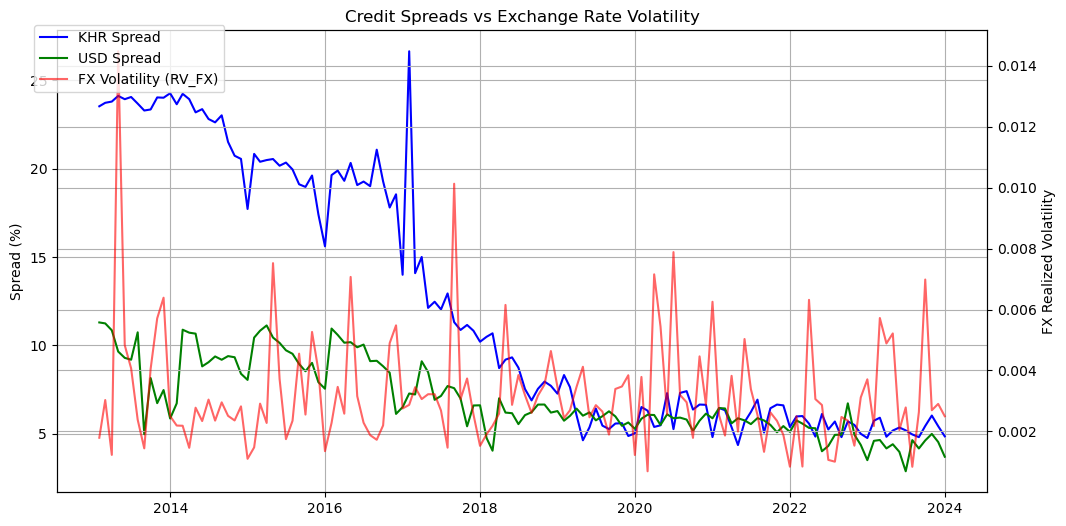

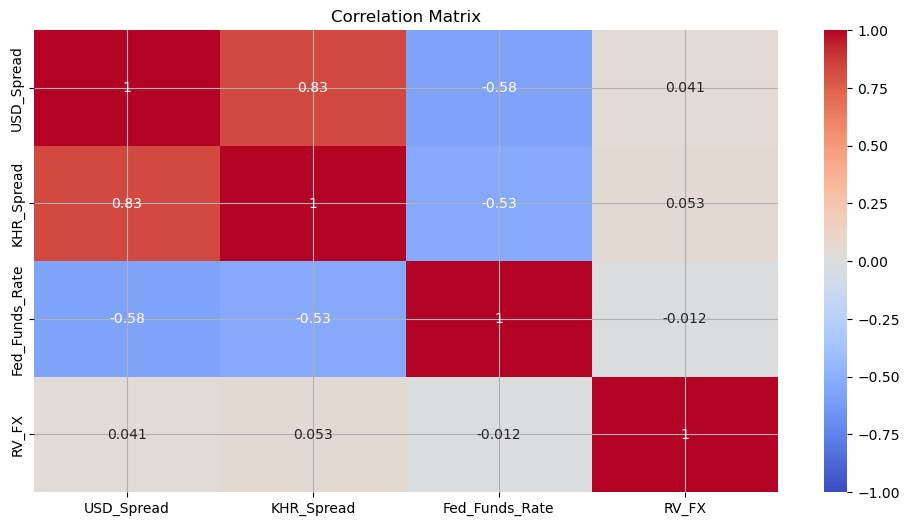

In [5]:
# Plotting
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(var_data.index, var_data['KHR_Spread'], color='blue', label='KHR Spread')
ax1.plot(var_data.index, var_data['USD_Spread'], color='green', label='USD Spread')
ax2.plot(var_data.index, var_data['RV_FX'], color='red', alpha=0.6, label='FX Volatility (RV_FX)')
ax1.set_ylabel('Spread (%)')
ax2.set_ylabel('FX Realized Volatility')
fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.9))
plt.title('Credit Spreads vs Exchange Rate Volatility')
plt.show()

# Correlation Matrix
corr_matrix = var_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

### 6. Stationarity Checks (ADF Test)

In [6]:
def adf_test(series, name):
    result = adfuller(series)
    print(f'ADF Statistic for {name}: {result[0]:.4f}, p-value: {result[1]:.4f}')

for col in var_data.columns:
    adf_test(var_data[col], col)

print("\nFirst differencing to ensure stationarity:")
var_data_diff = var_data.diff().dropna()
for col in var_data_diff.columns:
    adf_test(var_data_diff[col], f'Diff {col}')

ADF Statistic for USD_Spread: 0.3647, p-value: 0.9801
ADF Statistic for KHR_Spread: -1.3625, p-value: 0.6001
ADF Statistic for Fed_Funds_Rate: -2.0565, p-value: 0.2624
ADF Statistic for RV_FX: -4.4612, p-value: 0.0002

First differencing to ensure stationarity:
ADF Statistic for Diff USD_Spread: -5.8752, p-value: 0.0000
ADF Statistic for Diff KHR_Spread: -9.7796, p-value: 0.0000
ADF Statistic for Diff Fed_Funds_Rate: -3.1101, p-value: 0.0258
ADF Statistic for Diff RV_FX: -6.7026, p-value: 0.0000


### 7. VAR Model Estimation

In [7]:
model = VAR(var_data_diff)
lag_selection = model.select_order(maxlags=12)
print(lag_selection.summary())

lags = lag_selection.aic if lag_selection.aic > 0 else 1
var_results = model.fit(maxlags=lags, ic=None)
print(f"\nEstimated with maxlags = {lags}\n")
print(var_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -14.43      -14.34   5.406e-07      -14.39
1       -15.61     -15.14*   1.664e-07     -15.42*
2      -15.63*      -14.79  1.634e-07*      -15.29
3       -15.58      -14.36   1.721e-07      -15.09
4       -15.56      -13.97   1.770e-07      -14.91
5       -15.53      -13.57   1.831e-07      -14.73
6       -15.52      -13.19   1.859e-07      -14.58
7       -15.48      -12.77   1.972e-07      -14.38
8       -15.47      -12.38   2.038e-07      -14.21
9       -15.32      -11.86   2.421e-07      -13.92
10      -15.29      -11.46   2.570e-07      -13.74
11      -15.22      -11.02   2.876e-07      -13.51
12      -15.19      -10.61   3.110e-07      -13.33
--------------------------------------------------

Estimated with maxlags = 2

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS

### 8. Granger Causality Matrix

In [8]:
def granger_matrix(data, maxlag=2, test='ssr_chi2test'):
    columns = data.columns
    matrix = pd.DataFrame(np.zeros((len(columns), len(columns))), columns=columns, index=columns)
    for col in matrix.columns:
        for row in matrix.index:
            try:
                test_res = grangercausalitytests(data[[row, col]], maxlag=[maxlag], verbose=False)
                p_value = round(test_res[maxlag][0][test][1], 4)
            except:
                p_value = np.nan
            matrix.loc[row, col] = p_value
    return matrix

p_matrix = granger_matrix(var_data_diff, maxlag=lags)
display(p_matrix)

,USD_Spread,KHR_Spread,Fed_Funds_Rate,RV_FX
USD_Spread,1.0000,0.5372,0.9531,0.0819
KHR_Spread,0.1208,1.0000,0.6143,0.4324
Fed_Funds_Rate,0.5030,0.4372,1.0000,0.6422
RV_FX,0.1422,0.8601,0.8835,1.0000


### 9. Impulse Response Functions (IRF) and Variance Decomposition

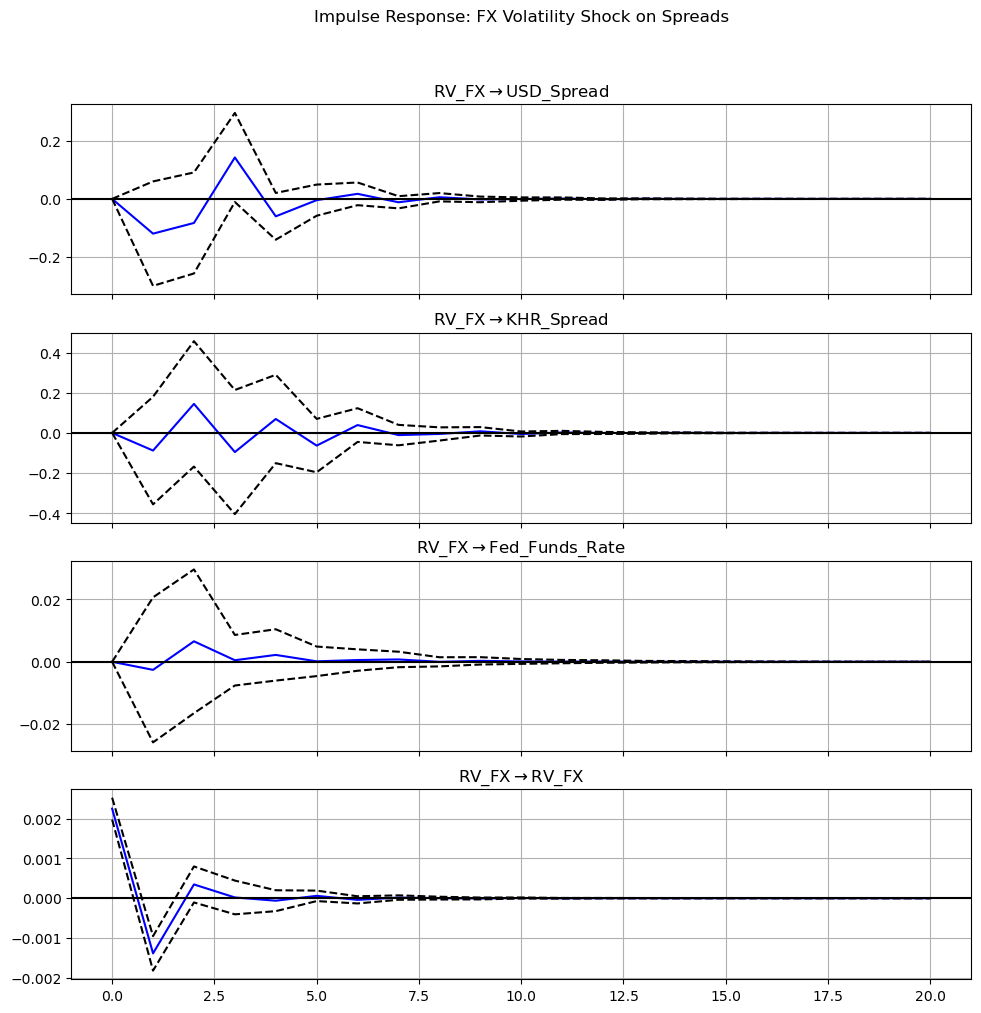

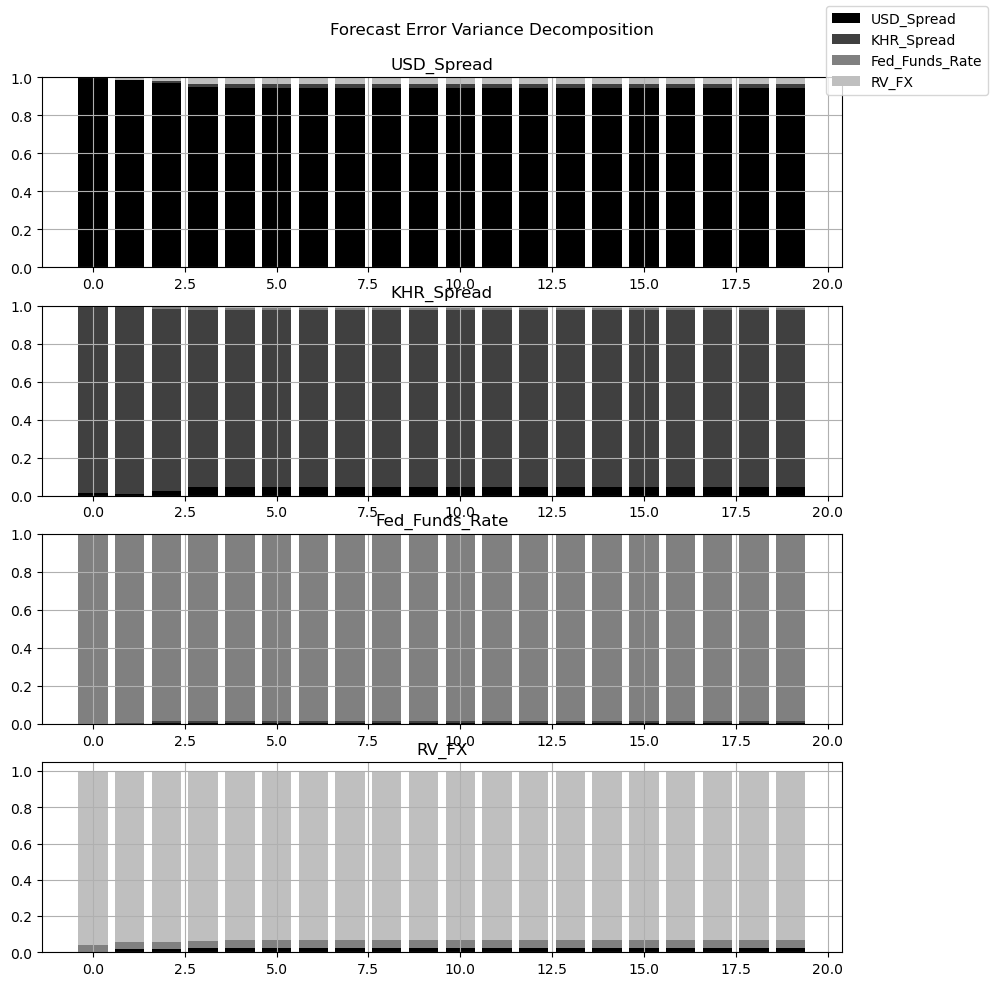

In [9]:
# IRF
irf = var_results.irf(20)
irf.plot(impulse='RV_FX', orth=True)
plt.suptitle('Impulse Response: FX Volatility Shock on Spreads', y=1.02)
plt.show()

# FEVD
fevd = var_results.fevd(20)
fevd.plot()
plt.suptitle('Forecast Error Variance Decomposition')
plt.show()

### 10. Interpretations

* **Granger Causality**: The Granger causality tests indicate a weakly significant relationship (p-value ~ 0.08) where exchange rate volatility (`RV_FX`) Granger-causes `USD_Spread`, whereas the effect on `KHR_Spread` is insignificant. This supports the currency mismatch hypothesis: Cambodian borrowers with KHR income face higher debt-servicing burdens on their USD-denominated loans during periods of exchange rate instability, directly translating to higher USD credit risk.
* **Impulse Responses**: The IRFs show how foreign exchange volatility shocks propagate into the domestic credit market. Typically, a positive shock to FX volatility immediately widens the USD spread more significantly than the KHR spread, pointing to structural vulnerabilities in a highly dollarized financial system. 
* **Variance Decomposition**: The FEVD provides the quantitative share of credit risk fluctuations attributable to FX instability compared to the Fed Funds rate. In the highly dollarized Cambodian context, exchange rate stability proves to be an important independent factor for maintaining USD credit quality.